In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
I_1 = 0.1 # [kg.m^2]
I_2 = 2 # [kg.m^2]
c = 10 # [N.m/rad]

In [ ]:
class TwoDOFTorsionalSystem:

    # Constructor to initialize the system parameters
    def __init__(self, I_1=0, I_2=0, c=0):
        self.I_1 = I_1
        self.I_2 = I_2
        self.c = c
        if self.I_1>0 and self.I_2>0 and self.c>0:
            self.omega_n = self.s_eq.calculate_natural_frequency()
        else:
            self.omega_n = None
    
    # Method to simulate the time response of the system
    def simulate_time_response(self, initial_angle=0, initial_velocity=0, time_span=10, load_type=["poly", "poly"], tau_ext=np.array([[0], [0]], dtype=np.float16)):
        t = np.zeros((int(1e3), 2))
        theta_t = np.zeros((int(1e3), 2))
        for i in range(2):
            t[:, i], theta_t[:, i] = self.s_eq.simulate_time_response(initial_angle=initial_angle[i], initial_velocity=initial_velocity[i], time_span=time_span, load_type=load_type[i], tau_ext=tau_ext[i])
        return t, theta_t

In [13]:
S = TwoDOFTorsionalSystem(I_1=I_1, I_2=I_2, c=c)
S.omega_n

np.float64(10.246950765959598)

In [ ]:
theta_0 = [1, 0]
theta_dot_0 = [0, 0]
t, theta_t = S.simulate_time_response(initial_angle=theta_0, initial_velocity=theta_dot_0)

(1000, 2)


"\n# Angular Acceleration vs Time\nangular_acceleration = np.gradient(angular_velocity, t)\naxes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')\naxes[2].set_xlabel('Time [s]')\naxes[2].set_ylabel('Angular Acceleration [rad/s^2]')\naxes[2].set_title('Angular Acceleration vs Time')\naxes[2].grid(True)\n\nplt.tight_layout(rect=[0, 0.03, 1, 0.95])"

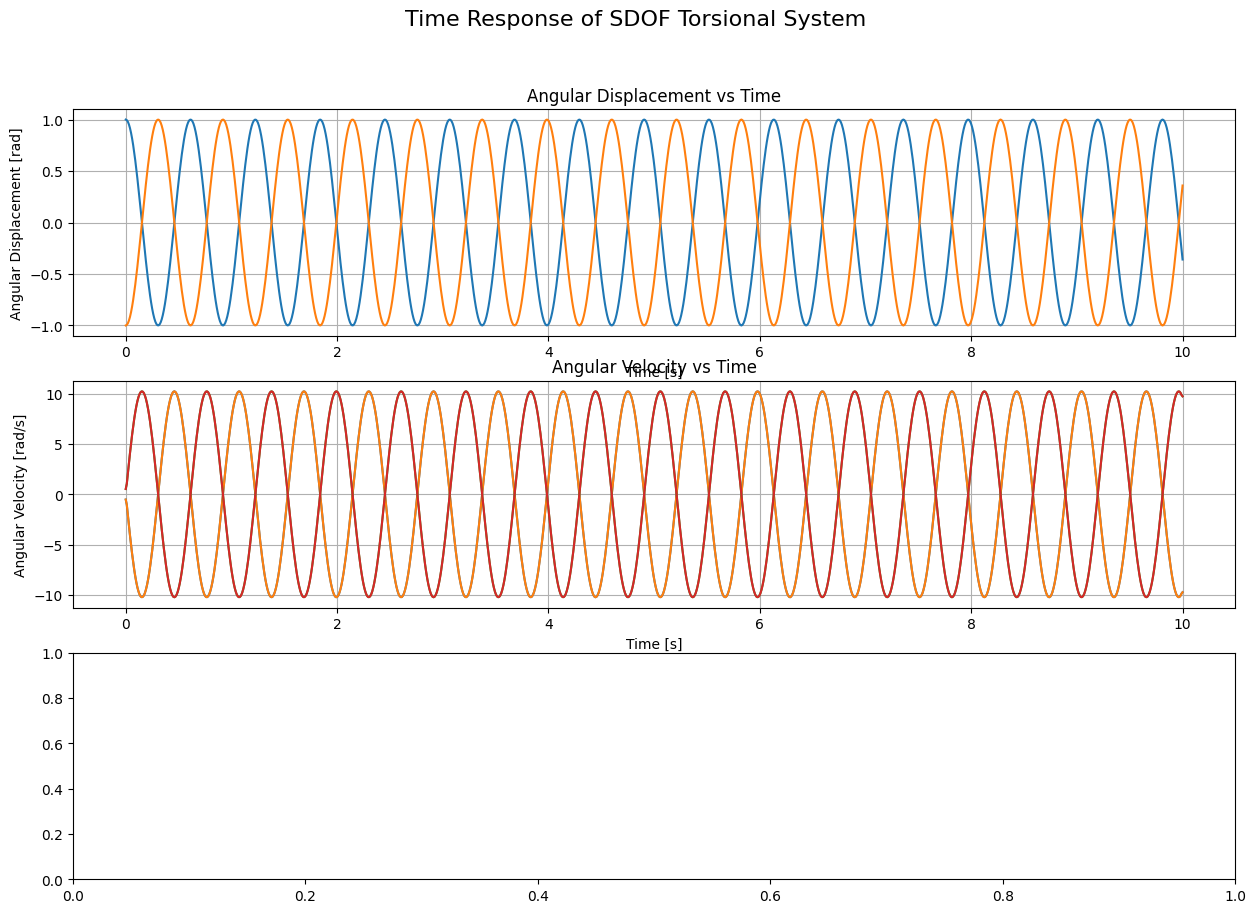

In [24]:
# Plotting the time response
fig, axes = plt.subplots(3, 1, figsize=(15, 10))
fig.suptitle('Time Response of SDOF Torsional System', fontsize=16)
# Angular Displacement vs Time
axes[0].plot(t[:, 0], theta_t[:, 0], label='Angular Displacement 1')
axes[0].plot(t[:, 1], theta_t[:, 1], label='Angular Displacement 2')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Angular Displacement [rad]')
axes[0].set_title('Angular Displacement vs Time')
axes[0].grid(True)

# Angular Velocity vs Time
angular_velocity = np.gradient(theta_t, t[:, 0], axis=0)
print(np.shape(angular_velocity))

axes[1].plot(t, angular_velocity[:, 0], label='Angular Velocity 1')
axes[1].plot(t, angular_velocity[:, 1], label='Angular Velocity 2')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Angular Velocity [rad/s]')
axes[1].set_title('Angular Velocity vs Time')
axes[1].grid(True)
'''
# Angular Acceleration vs Time
angular_acceleration = np.gradient(angular_velocity, t)
axes[2].plot(t, angular_acceleration, label='Angular Acceleration', color='green')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Angular Acceleration [rad/s^2]')
axes[2].set_title('Angular Acceleration vs Time')
axes[2].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])'''